# Pubmat Checker — Testing Notebook

Notebook for testing `checker.py`

| Function | Applicable to|
|---|---|
| `check_watermark()` | All except photo, resolution, advisory, quote |
| `check_readability()` | All except photo | 
| `check_pubmat_quality()` | All |
| `check_sgd()` | Advisory, resolution |
| `check_photo_quality()` | Photo |
| `check_logo_order()` | All |
| `logo_report()` | All |
| `generate_report()` | Full pipeline |

## 1. Imports and Setup

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import types
import torch
import pprint
pp = pprint.PrettyPrinter(indent=2)

from checker import (
    _run_doctr,
    _extract_ocr_data,
    check_watermark,
    check_readability,
    check_pubmat_quality,
    check_sgd,
    check_photo_quality,
    check_logo_order,
    logo_report,
    generate_report,
    POST_TYPE_RULES,
)



## 2. Load Test Image

Image loaded: 1638x2048 px, uint8


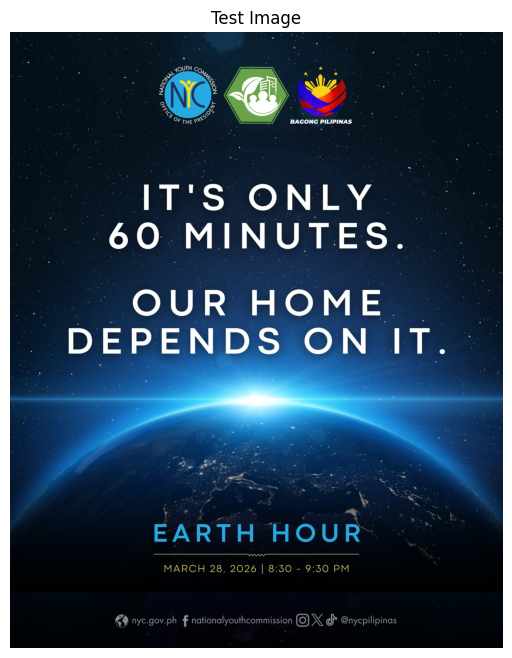

In [3]:
image_path = 'test.jpg' 

image = cv2.imread(image_path)

if image is None:
    print('ERROR: Failed to load image. Check the path.')
else:
    h, w = image.shape[:2]
    print(f'Image loaded: {w}x{h} px, {image.dtype}')
    plt.figure(figsize=(8, 8))
    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.title('Test Image')
    plt.axis('off')
    plt.show()

## 3. Run OCR Once
docTR is run once here and the results are reused by all checks below.

In [4]:
doctr_result = _run_doctr(image)
ocr_words, ocr_confidences, ocr_boxes = _extract_ocr_data(doctr_result)

print(f'Words detected : {len(ocr_words)}')
print(f'Avg confidence : {round(sum(ocr_confidences)/len(ocr_confidences), 3) if ocr_confidences else 0}')
print(f'Sample words   : {ocr_words[:20]}')

Words detected : 31
Avg confidence : 0.857
Sample words   : ['(Ou', 'VC', 'Co', 'OF', 'THE', 'PRERO', 'BAGONG', 'PILIPINAS', 'TS', 'ONLY', '60.', 'MINUTES.', 'OUR', 'HOME', 'DEPENDSONIT.', 'EARTH', 'HOUR', 'MARCH', '28,', '2026']


## 4. Check Readability
Composite score: 40% OCR confidence, 20% text size, 20% contrast, 20% blur.

In [ ]:

readability = check_readability(image, ocr_confidences, ocr_boxes)
pp.pprint(readability)

{ 'label': 'Readable',
  'pass': True,
  'readability_status': 'Readable',
  'remark': 'OK',
  'score': 0.862}


## 5. Check Watermark
Pass the pre-computed bottom-15% OCR words so no second docTR call is made.

In [8]:
# Filter full-image OCR to bottom 15% (y0 >= 0.85)
bottom_pairs = [(w, b) for w, b in zip(ocr_words, ocr_boxes) if b[1] >= 0.85]
wm_words = [p[0] for p in bottom_pairs]
wm_boxes = [p[1] for p in bottom_pairs]

print(f'Words in bottom 15%: {wm_words}')

wm_result = check_watermark(image, precomputed_words=wm_words, precomputed_boxes=wm_boxes)
pp.pprint(wm_result)

Words in bottom 15%: ['MARCH', '28,', '2026', 'I', '8:30', '-', '9:30', 'PM', 'nyc.gov.ph', 't', 'nationalyouthcommission', 'O', 'an', '@nycpilipinas']
{ 'boxes': [ (511, 1770, 651, 1798),
             (661, 1766, 721, 1806),
             (731, 1770, 823, 1800),
             (831, 1764, 851, 1806),
             (857, 1766, 940, 1802),
             (948, 1774, 973, 1798),
             (979, 1766, 1065, 1802),
             (1075, 1768, 1131, 1802),
             (405, 1940, 555, 1978),
             (573, 1946, 593, 1974),
             (603, 1940, 938, 1976),
             (957, 1938, 997, 1970),
             (1059, 1940, 1085, 1960),
             (1101, 1940, 1287, 1976)],
  'details': { '@nycpilipinas': {'found': True, 'score': 0.96},
               'nationalyouthcommission': {'found': True, 'score': 1.0},
               'nyc.gov.ph': {'found': True, 'score': 0.889}},
  'label': 'Watermark OK',
  'missing': [],
  'pass': True,
  'remark': 'OK',
  'watermark_present': True}


In [9]:
# Fallback: no pre-computed data — crops and re-runs docTR internally
wm_fallback = check_watermark(image)
print('Fallback result:')
pp.pprint(wm_fallback)

Fallback result:
{ 'boxes': [ (511, 1770, 647, 1798),
             (663, 1769, 716, 1801),
             (729, 1769, 820, 1799),
             (857, 1769, 937, 1799),
             (950, 1777, 970, 1794),
             (978, 1769, 1058, 1799),
             (1073, 1769, 1129, 1799),
             (403, 1940, 555, 1977),
             (569, 1938, 595, 1980),
             (601, 1938, 937, 1973),
             (950, 1930, 1044, 1977),
             (1046, 1933, 1087, 1973),
             (1100, 1938, 1286, 1975)],
  'details': { '@nycpilipinas': {'found': True, 'score': 0.96},
               'nationalyouthcommission': {'found': True, 'score': 1.0},
               'nyc.gov.ph': {'found': True, 'score': 0.889}},
  'label': 'Watermark OK',
  'missing': [],
  'pass': True,
  'remark': 'OK',
  'watermark_present': True}


## 6. Check pubmat quality
Runs for all post types. Checks resolution ≥ 720×720, blur variance ≥ 50, contrast std ≥ 30.

In [10]:
quality = check_pubmat_quality(image)
pp.pprint(quality)

{'label': 'Good quality', 'pass': True, 'remark': 'OK'}


## 7. Check SGD
Applied to: `advisory`, `resolution`. Uses whole-word regex `\bsgd\b` — partial matches like `msgd` or `sgds` do not count.

In [12]:
# Unit tests
test_cases = [
    (['Pursuant', 'to', 'SGD', 'No.', '123'],  True),
    (['sgd', 'approved', 'by', 'the', 'board'], True),
    (['no', 'relevant', 'keyword', 'here'],      False),
    (['msgd', 'resolution', 'passed'],           False),  
    (['sgds', 'are', 'required'],                False),  
]

print('check_sgd() unit tests:')
all_ok = True
for words, expected in test_cases:
    result = check_sgd(words)
    ok = result['pass'] == expected
    if not ok: all_ok = False
    print(f'  {words}  → pass={result["pass"]} (expected {expected})')
print('All tests passed!' if all_ok else 'Some tests failed.')

check_sgd() unit tests:
  ['Pursuant', 'to', 'SGD', 'No.', '123']  → pass=True (expected True)
  ['sgd', 'approved', 'by', 'the', 'board']  → pass=True (expected True)
  ['no', 'relevant', 'keyword', 'here']  → pass=False (expected False)
  ['msgd', 'resolution', 'passed']  → pass=False (expected False)
  ['sgds', 'are', 'required']  → pass=False (expected False)
All tests passed!


In [13]:
# Run against actual OCR output from the loaded image
sgd_result = check_sgd(ocr_words)
pp.pprint(sgd_result)

{'pass': False, 'remark': 'Use SGD for resolutions/advisories'}


## 8. Check Photo Quality
Applied to: `photo`. Checks resolution ≥ 1080×1080, brightness ≥ 60, saturation ≥ 20.

In [15]:
image = cv2.imread("6.jpg")
photo_result = check_photo_quality(image, min_resolution=(1080, 1080))
pp.pprint(photo_result)

{ 'details': { 'brightness': 102.4,
               'mean_saturation': 123.7,
               'resolution': '1920x1080 (required 1080x1080)'},
  'label': 'Photo quality OK',
  'pass': True,
  'remark': 'OK'}


In [16]:
# Test with a relaxed resolution requirement
photo_result_720 = check_photo_quality(image, min_resolution=(720, 720))
print('With 720x720 minimum:')
pp.pprint(photo_result_720)

With 720x720 minimum:
{ 'details': { 'brightness': 102.4,
               'mean_saturation': 123.7,
               'resolution': '1920x1080 (required 720x720)'},
  'label': 'Photo quality OK',
  'pass': True,
  'remark': 'OK'}


## 9. Logo Order Check
Runs for all post types. NYC must be leftmost, BP rightmost, SK/YORP between them if required.

In [ ]:
def make_mock_box(x0, y0, x1, y1):
    box = types.SimpleNamespace()
    box.xyxy = torch.tensor([[x0, y0, x1, y1]], dtype=torch.float32)
    return box

# Correct order: NYC → SK → BP
mock_detected = {
    'nyc':  {'status': 'correct', 'conf': 0.92, 'box': make_mock_box(10,  10, 80,  80)},
    'bp':   {'status': 'correct', 'conf': 0.88, 'box': make_mock_box(900, 10, 980, 80)},
    'sk':   {'status': 'correct', 'conf': 0.80, 'box': make_mock_box(450, 10, 530, 80)},
    'yorp': None,
}
order_result = check_logo_order(mock_detected, collaborators=['sk'])
pp.pprint(order_result)
assert order_result['pass'], 'Expected NYC → SK → BP to pass'

{ 'details': { 'order': 'NYC → SK → BP',
               'positions': { 'bp': np.float64(940.0),
                              'nyc': np.float64(45.0),
                              'sk': np.float64(490.0)}},
  'detected_order': 'NYC → SK → BP',
  'label': 'Logo order OK',
  'order_valid': True,
  'pass': True,
  'remark': 'OK'}


In [20]:
# Wrong order: SK is to the left of NYC
mock_wrong_order = {
    'nyc':  {'status': 'correct', 'conf': 0.92, 'box': make_mock_box(200, 10, 280, 80)},
    'bp':   {'status': 'correct', 'conf': 0.88, 'box': make_mock_box(900, 10, 980, 80)},
    'sk':   {'status': 'correct', 'conf': 0.80, 'box': make_mock_box(10,  10, 90,  80)},
    'yorp': None,
}
wrong_order = check_logo_order(mock_wrong_order, collaborators=['sk'])
pp.pprint(wrong_order)
assert not wrong_order['pass'], 'Expected order check to fail'

{ 'details': { 'order': 'SK → NYC → BP',
               'positions': { 'bp': np.float64(940.0),
                              'nyc': np.float64(240.0),
                              'sk': np.float64(50.0)}},
  'detected_order': 'SK → NYC → BP',
  'label': 'Logo order issues',
  'order_valid': False,
  'pass': False,
  'remark': 'NYC should be leftmost | SK should be to the right of NYC'}


In [21]:
# Missing BP — should early-return
mock_missing_bp = {
    'nyc':  {'status': 'correct', 'conf': 0.92, 'box': make_mock_box(10, 10, 80, 80)},
    'bp':   None,
    'sk':   None,
    'yorp': None,
}
missing_result = check_logo_order(mock_missing_bp)
pp.pprint(missing_result)
assert not missing_result['pass']

{ 'details': {},
  'label': 'Cannot check order',
  'order_valid': False,
  'pass': False,
  'remark': 'NYC or BP not detected'}


## 10. Post Type Rules — Verify Flags

In [22]:
print('POST_TYPE_RULES summary:\n')
for ptype, rules in POST_TYPE_RULES.items():
    flags = []
    if rules.get('requires_watermark'):  flags.append('watermark')
    if rules.get('requires_sgd'):        flags.append('sgd')
    if rules.get('check_photo_quality'): flags.append('photo_quality')
    threshold = rules.get('readability_threshold', '—')
    print(f'  {ptype:<12} readability>={threshold}   {"  ".join(flags) if flags else "(no extra checks)"}')

# Spot-check expected flags
assert POST_TYPE_RULES['advisory']['requires_sgd'],           'advisory should require SGD'
assert POST_TYPE_RULES['resolution']['requires_sgd'],         'resolution should require SGD'
assert POST_TYPE_RULES['photo']['check_photo_quality'],       'photo should check photo quality'
assert POST_TYPE_RULES['news']['requires_watermark'],         'news should require watermark'
assert 'strict_logo_order' not in POST_TYPE_RULES['advisory'], 'strict_logo_order should not exist'
print('\n✅ All flag assertions passed')

POST_TYPE_RULES summary:

  news         readability>=0.65   watermark
  quotes       readability>=0.6   (no extra checks)
  advisory     readability>=0.7   sgd
  resolution   readability>=0.7   sgd
  hiring       readability>=0.65   watermark
  photo        readability>=0.5   photo_quality
  holiday      readability>=0.5   watermark
  other        readability>=0.5   watermark

✅ All flag assertions passed


## 11. Full Report 


In [ ]:
from ultralytics import YOLO

image = cv2.imread('test.jpg')  #  test image
model = YOLO('best_v3.pt')      # model path
yolo_results = model(image)

audit, annotated = generate_report(
    yolo_results,
    model,
    image,
    post_type='photo',  # change to test other post types
    collaborators=['sk'],  # add 'sk' or 'yorp' if needed
)

pp.pprint(audit)


0: 640x512 1 NYC_Correct, 1 BP_Correct, 1 SK_Correct, 426.0ms
Speed: 5.9ms preprocess, 426.0ms inference, 1.7ms postprocess per image at shape (1, 3, 640, 512)
{ 'logo_order': { 'details': { 'order': 'NYC → SK → BP',
                               'positions': { 'bp': np.float64(424.5),
                                              'nyc': np.float64(185.5),
                                              'sk': np.float64(314.0)}},
                  'detected_order': 'NYC → SK → BP',
                  'label': 'Logo order OK',
                  'order_valid': True,
                  'pass': True,
                  'remark': 'OK'},
  'logos': [ { 'Confidence': 0.968,
               'Detected': 'Yes',
               'Logo': 'NYC',
               'Remark': 'Logo is correct',
               'Status': 'Correct'},
             { 'Confidence': 0.983,
               'Detected': 'Yes',
               'Logo': 'BP',
               'Remark': 'Logo is correct',
               'Status': 'Correct'},
  

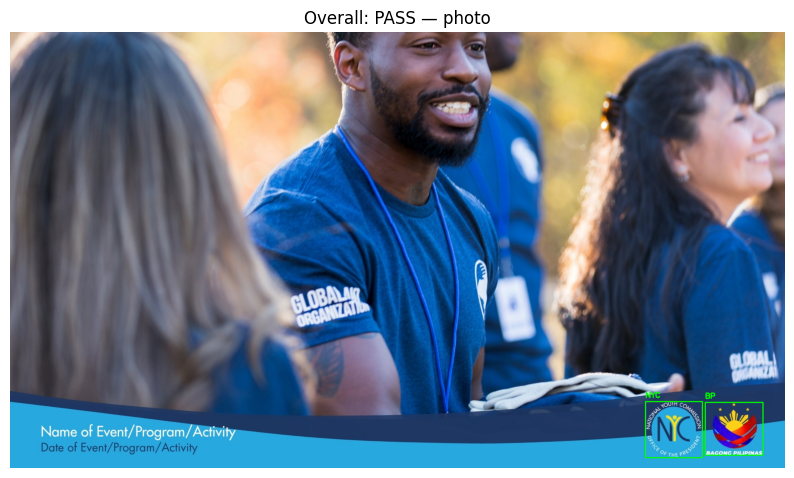

In [25]:
plt.figure(figsize=(10, 10))
plt.imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
plt.title(f"Overall: {audit['overall']} — {audit['post_type']}")
plt.axis('off')
plt.show()

In [26]:
# advisory — should include sgd in type_checks
audit_advisory, _ = generate_report(yolo_results, model, image, post_type='advisory')
pp.pprint(audit_advisory['type_checks'])
assert 'sgd' in audit_advisory['type_checks']['checks'], 'SGD check should run for advisory'
assert 'photo_quality' not in audit_advisory['type_checks']['checks'], 'photo_quality should NOT run for advisory'

{ 'checks': { 'readability': { 'pass': True,
                               'remark': 'OK',
                               'score': 0.776,
                               'threshold': 0.7},
              'sgd': { 'pass': False,
                       'remark': 'Use SGD for resolutions/advisories'}},
  'post_type': 'advisory',
  'status': 'Fail'}


In [ ]:
# photo — should include photo_quality, not sgd
audit_photo, _ = generate_report(yolo_results, model, image, post_type='photo')
pp.pprint(audit_photo['type_checks'])
assert 'photo_quality' in audit_photo['type_checks']['checks'], 'photo_quality check should run for photo'
assert 'sgd' not in audit_photo['type_checks']['checks'], 'SGD check should NOT run for photo'